In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#upload = files.upload()

In [3]:
df = pd.read_csv(r"..\data\battery_synthetic_dataset.csv")
df.head()

,avg_voltage,avg_temperature,battery_life_months,cycle_count,label
0,3.327,39.19,61.5,1127,0
1,3.419,34.96,40.8,861,0
2,3.456,44.52,59.3,1131,0
3,3.292,39.37,49.5,1096,0
4,3.196,35.65,48.1,1045,0


In [4]:
data = df.copy()

X = data.drop("label", axis=1)
y = data["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
input_size = X_train.shape[1]
hidden1_size = 8
hidden2_size = 5
output_size = 1

In [8]:
def relu(x):
    return np.maximum(0, x)
def relu_derivative(x):
    return (x > 0).astype(float)

In [9]:
rng = np.random.default_rng(42)
def he_init(fan_in, fan_out):
    return rng.standard_normal((fan_in, fan_out)) * np.sqrt(2 / fan_in)

In [10]:
weight_input_hidden1 = he_init(input_size, hidden1_size)
bias_input_hidden1 = np.zeros((1, hidden1_size))

weight_hidden1_hidden2 = he_init(hidden1_size, hidden2_size)
bias_hidden1_hidden2 = np.zeros((1, hidden2_size))

weight_hidden2_output = he_init(hidden2_size, output_size)
bias_hidden2_output = np.zeros((1, output_size))

In [11]:
epochs = 10000
learning_rate = 1e-2
n = X_train.shape[0]

In [12]:
for epoch in range(epochs):

    # Forward Propagation
    hidden1_input = np.dot(X_train, weight_input_hidden1) + bias_input_hidden1
    hidden1_output = relu(hidden1_input)

    hidden2_input = np.dot(hidden1_output, weight_hidden1_hidden2) + bias_hidden1_hidden2
    hidden2_output = relu(hidden2_input)

    output_input = np.dot(hidden2_output, weight_hidden2_output) + bias_hidden2_output
    output = relu(output_input)

    # Error Calculation
    error = y_train.to_numpy().reshape(-1, 1) - output


    # Backpropagation
    delta_output = error * relu_derivative(output_input)
    delta_hidden2 = (delta_output.dot(weight_hidden2_output.T) * relu_derivative(hidden2_output))
    delta_hidden1 = (delta_hidden2.dot(weight_hidden1_hidden2.T) * relu_derivative(hidden1_output))


    # Updating Weights and Biases
    weight_hidden2_output += (learning_rate * hidden2_output.T.dot(delta_output) / n)
    bias_hidden2_output += learning_rate * np.mean(delta_output,axis=0,keepdims=True)
    weight_hidden1_hidden2 += (learning_rate * hidden1_output.T.dot(delta_hidden2) / n)
    bias_hidden1_hidden2 += learning_rate * np.mean(delta_hidden2,axis=0,keepdims=True)
    weight_input_hidden1 += (learning_rate * X_train.T.dot(delta_hidden1) / n)
    bias_input_hidden1 += learning_rate * np.mean(delta_hidden1,axis=0,keepdims=True)

    if (epoch + 1) % 1000 == 0 or epoch == 0:
        loss = np.mean(error ** 2)
        print(f"Epoch {epoch + 1}, Loss: {loss}")

Epoch 1, Loss: 0.5763272598560341
Epoch 1000, Loss: 0.07517350725223762
Epoch 2000, Loss: 0.07020386290263063
Epoch 3000, Loss: 0.06852025747686163
Epoch 4000, Loss: 0.06775432208831594
Epoch 5000, Loss: 0.06738070224314041
Epoch 6000, Loss: 0.06710382488226192
Epoch 7000, Loss: 0.06678981119721966
Epoch 8000, Loss: 0.06655972702566841
Epoch 9000, Loss: 0.06638332126555285
Epoch 10000, Loss: 0.06624671340667598


In [13]:
# Prediction on Test Data
hidden1_input = np.dot(X_test, weight_input_hidden1) + bias_input_hidden1
hidden1_output = relu(hidden1_input)

hidden2_input = np.dot(hidden1_output, weight_hidden1_hidden2) + bias_hidden1_hidden2
hidden2_output = relu(hidden2_input)

output_input = np.dot(hidden2_output, weight_hidden2_output) + bias_hidden2_output
output = relu(output_input)

              precision    recall  f1-score   support

           0       0.85      0.95      0.90        73
           1       0.97      0.91      0.93       127

    accuracy                           0.92       200
   macro avg       0.91      0.93      0.92       200
weighted avg       0.92      0.92      0.92       200



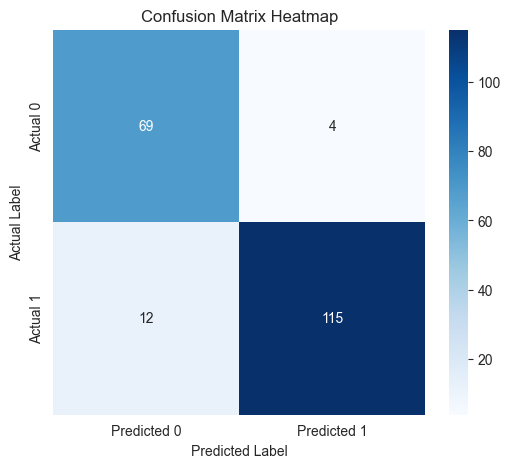

In [14]:
predicted_labels = (output > 0.5).astype(int)
print(classification_report(y_test, predicted_labels))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predicted_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()